# Module 1: Modeling Soil Cd Bioaccessibility

Objective: predict gastric-phase Cd bioaccessibility (BA_GP) using soil properties, total Cd concentration, soil source type, and in vitro digestion method.

Main evaluation: 5-fold cross-validation.
Additional visualization: 80/20 train-test split for observed vs predicted plot.

Import packages and load data

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [3]:
BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

data_path = BASE_DIR / "data" / "processed_data" / "processed_bioaccessibility.csv"
fig_dir = BASE_DIR / "figures"
result_dir = BASE_DIR / "results"

fig_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)

processed_bio = pd.read_csv(data_path, encoding="utf-8-sig")

print(processed_bio.shape)
processed_bio.head()

(190, 18)


,Number,Site,Type,Method,pH,SOM,Clay,Silt,Sand,Fe,T_Cd,GP,IP,BA_GP,BA_IP,log_T_Cd,log_GP,log_IP
0,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.98,27.99,1.70,48.20,50.10,33.150080,2.91,0.908502,0.704511,31.22,24.21,1.363537,0.646319,0.533278
1,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.07,73.91,0.02,36.36,63.62,66.904483,2.06,0.791452,0.555582,38.42,26.97,1.118415,0.583026,0.441850
2,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,5.87,43.02,0.65,25.98,73.37,37.976127,1.25,0.631875,0.554000,50.55,44.32,0.810930,0.489730,0.440832
3,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.01,66.52,0.51,19.77,79.71,67.569832,1.68,0.588336,0.523824,35.02,31.18,0.985817,0.462687,0.421223
4,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,5.75,46.44,0.02,22.20,77.78,63.906229,2.39,0.580531,0.544442,24.29,22.78,1.220830,0.457761,0.434663


Define target and features

In [4]:
target = "BA_GP"

numeric_features = [
    "pH", "SOM", "Clay", "Silt", "Sand", "Fe", "log_T_Cd"
]

categorical_features = [
    "Type", "Method"
]

features = numeric_features + categorical_features

model_processed_bio = processed_bio[features + [target]].dropna().copy()

X = model_processed_bio[features]
y = model_processed_bio[target]

print("Modeling dataset:", model_processed_bio.shape)
print("Target:", target)
print("Features:", features)

model_processed_bio.head()

Modeling dataset: (190, 10)
Target: BA_GP
Features: ['pH', 'SOM', 'Clay', 'Silt', 'Sand', 'Fe', 'log_T_Cd', 'Type', 'Method']


,pH,SOM,Clay,Silt,Sand,Fe,log_T_Cd,Type,Method,BA_GP
0,6.98,27.99,1.70,48.20,50.10,33.150080,1.363537,Mining/smelting soils,SBRC,31.22
1,6.07,73.91,0.02,36.36,63.62,66.904483,1.118415,Mining/smelting soils,SBRC,38.42
2,5.87,43.02,0.65,25.98,73.37,37.976127,0.810930,Mining/smelting soils,SBRC,50.55
3,6.01,66.52,0.51,19.77,79.71,67.569832,0.985817,Mining/smelting soils,SBRC,35.02
4,5.75,46.44,0.02,22.20,77.78,63.906229,1.220830,Mining/smelting soils,SBRC,24.29


Preprocessing pipeline

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Evaluate Function

In [6]:
def evaluate_models(X, y, models, cv, feature_group_name):
    results = []

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        results.append({
            "Feature_group": feature_group_name,
            "Model": model_name,
            "MAE_mean": -scores["test_mae"].mean(),
            "MAE_sd": scores["test_mae"].std(),
            "RMSE_mean": -scores["test_rmse"].mean(),
            "RMSE_sd": scores["test_rmse"].std(),
            "R2_mean": scores["test_r2"].mean(),
            "R2_sd": scores["test_r2"].std()
        })

    return pd.DataFrame(results)

Total-Cd-only baseline

In [7]:
baseline_features = ["log_T_Cd"]
target = "BA_GP"
baseline_data = processed_bio.dropna(subset=[target]).copy()
X_baseline = processed_bio[baseline_features]
y_baseline = processed_bio[target]

baseline_models = {
    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            min_samples_leaf=3
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3
        ))
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_results = evaluate_models(
    X_baseline,
    y_baseline,
    baseline_models,
    cv,
    "Total-Cd-only"
)

baseline_results

,Feature_group,Model,MAE_mean,MAE_sd,RMSE_mean,RMSE_sd,R2_mean,R2_sd
0,Total-Cd-only,Ridge Regression,21.975360,2.483942,25.949010,2.653811,0.104991,0.071729
1,Total-Cd-only,Random Forest,21.552829,2.999789,26.454915,3.610881,0.071293,0.133414
2,Total-Cd-only,Gradient Boosting,20.948681,2.431956,27.066994,3.482847,0.027553,0.125573


Model comparison with 5-fold cross-validation

In [8]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=3
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    )
}

results = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    results.append({
        "Model": model_name,
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_sd": scores["test_mae"].std(),
        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_sd": scores["test_rmse"].std(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_sd": scores["test_r2"].std()
    })

results_df = pd.DataFrame(results)
results_df
results_df.to_csv(
    result_dir / "model_performance_ba_gp.csv",
    index=False,
    encoding="utf-8-sig"
)

Comprison of all models

In [9]:
results_df["Feature_group"] = "Full-feature"
model_comparison_all = pd.concat(
    [baseline_results, results_df],
    ignore_index=True
)

model_comparison_all


,Feature_group,Model,MAE_mean,MAE_sd,RMSE_mean,RMSE_sd,R2_mean,R2_sd
0,Total-Cd-only,Ridge Regression,21.975360,2.483942,25.949010,2.653811,0.104991,0.071729
1,Total-Cd-only,Random Forest,21.552829,2.999789,26.454915,3.610881,0.071293,0.133414
2,Total-Cd-only,Gradient Boosting,20.948681,2.431956,27.066994,3.482847,0.027553,0.125573
3,Full-feature,Ridge Regression,19.914419,1.772489,24.594211,2.035305,0.194870,0.035423
4,Full-feature,Random Forest,16.378512,3.191153,20.534011,3.772341,0.438168,0.138616
5,Full-feature,Gradient Boosting,16.561027,3.114994,21.182560,4.383871,0.391841,0.198810


In [10]:
model_comparison_all.to_csv(
    result_dir / "model_comparison_baseline_vs_full.csv",
    index=False,
    encoding="utf-8-sig"
)

Plot comprison of MAE

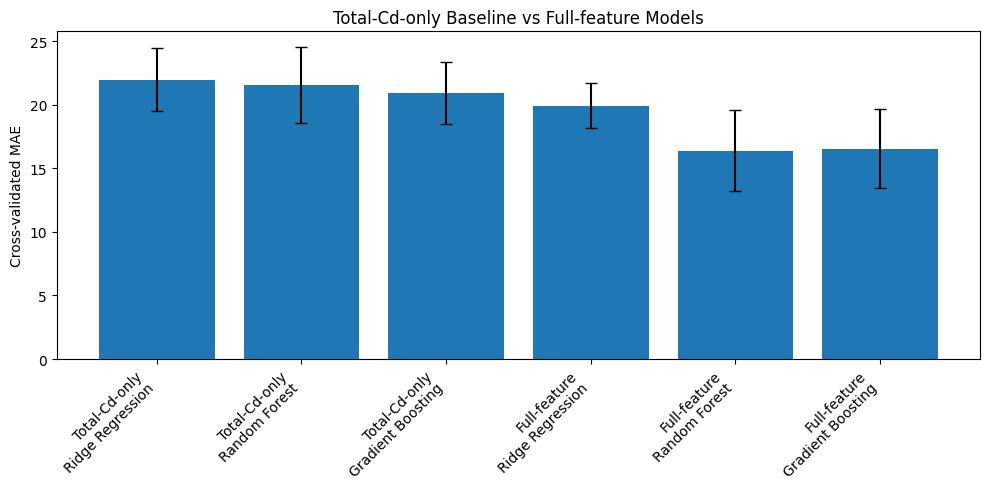

In [11]:
plot_df = model_comparison_all.copy()
plot_df["Label"] = plot_df["Feature_group"] + "\n" + plot_df["Model"]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Label"], plot_df["MAE_mean"], yerr=plot_df["MAE_sd"], capsize=4)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validated MAE")
plt.title("Total-Cd-only Baseline vs Full-feature Models")
plt.tight_layout()
plt.savefig(fig_dir / "baseline_vs_full_model_mae.png", dpi=300)
plt.show()

Plot comprison of R^2

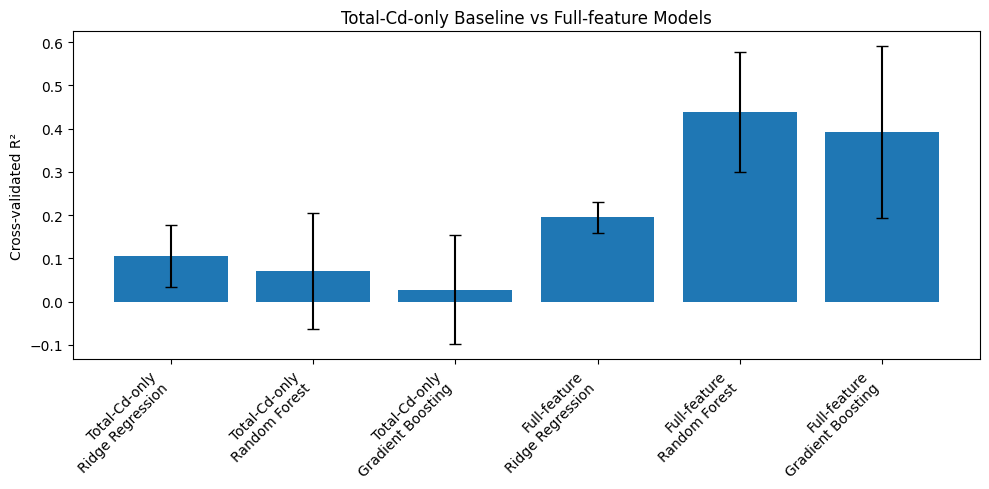

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Label"], plot_df["R2_mean"], yerr=plot_df["R2_sd"], capsize=4)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validated R²")
plt.title("Total-Cd-only Baseline vs Full-feature Models")
plt.tight_layout()
plt.savefig(fig_dir / "baseline_vs_full_model_r2.png", dpi=300)
plt.show()

Plot model performance

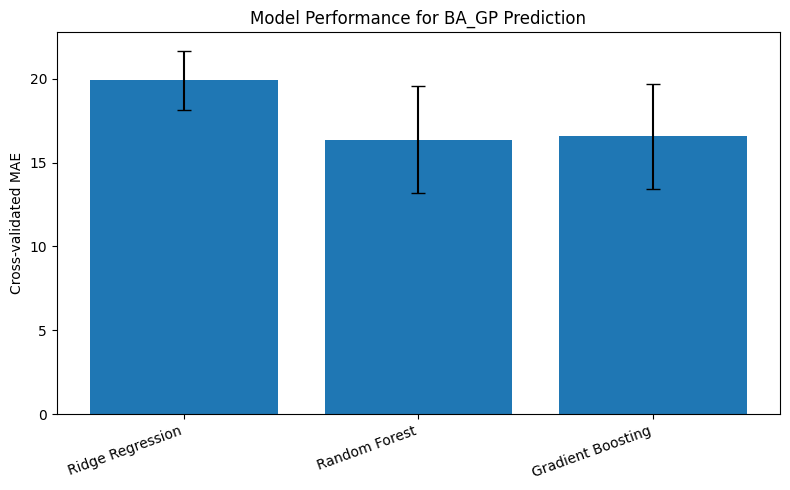

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["MAE_mean"],
    yerr=results_df["MAE_sd"],
    capsize=5
)
plt.ylabel("Cross-validated MAE")
plt.title("Model Performance for BA_GP Prediction")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "model_performance_mae_ba_gp.png", dpi=300)
plt.show()

Observed vs predicted plot

In [14]:
best_model_name = results_df.sort_values("MAE_mean").iloc[0]["Model"]
best_model_name

'Random Forest'

In [15]:
best_estimator = models[best_model_name]

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_estimator)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Best model:", best_model_name)
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

Best model: Random Forest
Test MAE: 21.745202204615858
Test RMSE: 26.717002484819258
Test R2: 0.19422249068612596


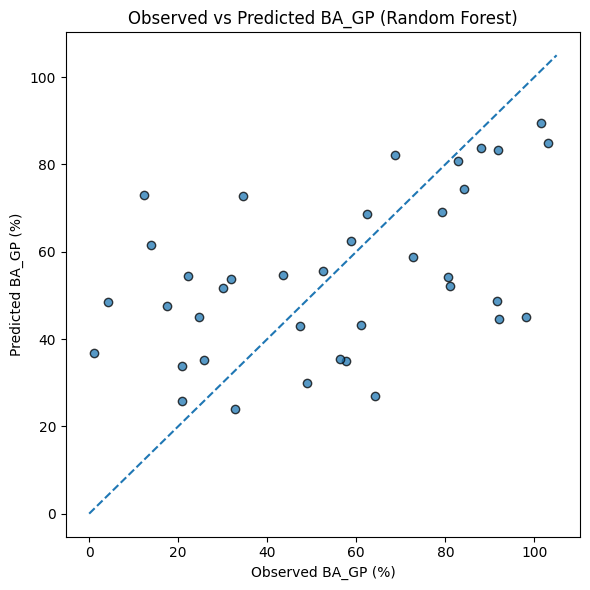

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")
plt.plot([0, 105], [0, 105], linestyle="--")
plt.xlabel("Observed BA_GP (%)")
plt.ylabel("Predicted BA_GP (%)")
plt.title(f"Observed vs Predicted BA_GP ({best_model_name})")
plt.tight_layout()
plt.savefig(fig_dir / "predicted_vs_observed_ba_gp.png", dpi=300)
plt.show()

Method and Type Effects on BA_GP

In [18]:
group_summary_method = (
    processed_bio
    .dropna(subset=["Method", "BA_GP"])
    .groupby("Method")["BA_GP"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values("median", ascending=False)
)

group_summary_type = (
    processed_bio
    .dropna(subset=["Type", "BA_GP"])
    .groupby("Type")["BA_GP"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values("median", ascending=False)
)

group_summary_method, group_summary_type

(  Method    n       mean  median        std       q1       q3
 2   SBET    2  85.225000  85.225   9.581297  81.8375  88.6125
 4    UBM   35  61.948857  70.590  25.506293  41.1500  79.9350
 0    IVG   15  64.783667  69.510  25.187540  56.2750  82.0450
 3   SBRC   23  63.111739  62.490  29.317405  37.9200  91.2600
 1   PBET  115  45.109762  43.780  26.269937  24.5500  60.9750,
                     Type   n       mean  median        std         q1      q3
 3            Urban soils  27  66.428333   76.70  22.668130  53.800000  83.670
 2  Mining/smelting soils  79  52.853177   54.55  25.376374  33.860000  71.430
 1       Industrial soils  41  46.674188   42.81  29.347703  26.470588  74.890
 0     Agricultural soils  43  48.069767   38.35  30.687300  23.195000  74.515)

In [19]:
group_summary_method.to_csv(result_dir / "ba_gp_summary_by_method.csv", index=False, encoding="utf-8-sig")
group_summary_type.to_csv(result_dir / "ba_gp_summary_by_type.csv", index=False, encoding="utf-8-sig")

Plot the distribution of BA_GP in different method

C:\Users\Shangrs\AppData\Local\Temp\ipykernel_35676\3351149776.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_method, labels=method_order, showfliers=True)


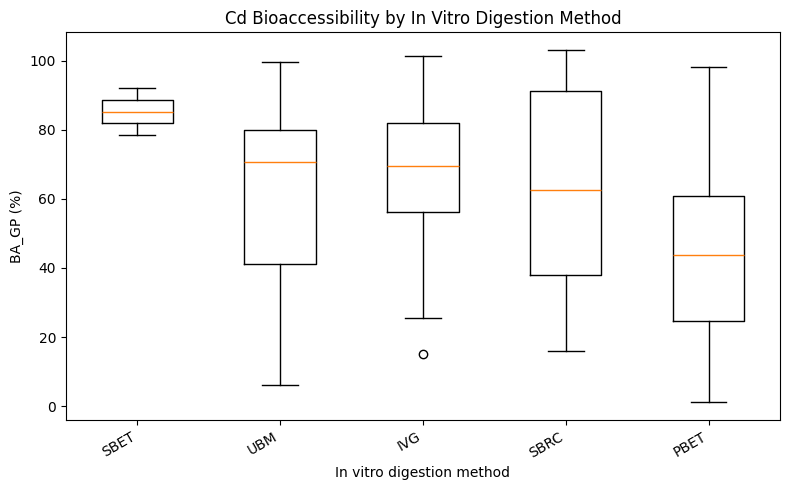

In [20]:
method_order = group_summary_method["Method"].tolist()

data_by_method = [
    processed_bio.loc[processed_bio["Method"] == m, "BA_GP"].dropna()
    for m in method_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_method, labels=method_order, showfliers=True)
plt.xticks(rotation=30, ha="right")
plt.xlabel("In vitro digestion method")
plt.ylabel("BA_GP (%)")
plt.title("Cd Bioaccessibility by In Vitro Digestion Method")
plt.tight_layout()
plt.savefig(fig_dir / "ba_gp_by_method_h2.png", dpi=300)
plt.show()

Plot the distribution of BA_GP in different type

C:\Users\Shangrs\AppData\Local\Temp\ipykernel_35676\1705435170.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_type, labels=type_order, showfliers=True)


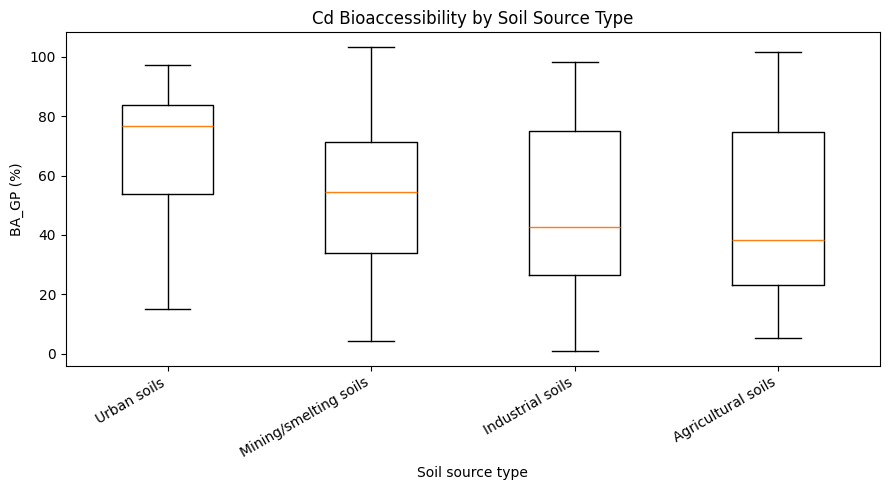

In [21]:
type_order = group_summary_type["Type"].tolist()

data_by_type = [
    processed_bio.loc[processed_bio["Type"] == t, "BA_GP"].dropna()
    for t in type_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(data_by_type, labels=type_order, showfliers=True)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Soil source type")
plt.ylabel("BA_GP (%)")
plt.title("Cd Bioaccessibility by Soil Source Type")
plt.tight_layout()
plt.savefig(fig_dir / "ba_gp_by_type_h2.png", dpi=300)
plt.show()

Kruskal-Wallis test

In [22]:
from scipy.stats import kruskal

method_groups = [
    processed_bio.loc[processed_bio["Method"] == m, "BA_GP"].dropna()
    for m in processed_bio["Method"].dropna().unique()
]

# 只保留样本量至少为 2 的组
method_groups = [g for g in method_groups if len(g) >= 2]

method_stat, method_p = kruskal(*method_groups)

print("Kruskal-Wallis test for BA_GP among Methods")
print(f"H-statistic: {method_stat:.3f}")
print(f"p-value: {method_p:.4f}")

type_groups = [
    processed_bio.loc[processed_bio["Type"] == t, "BA_GP"].dropna()
    for t in processed_bio["Type"].dropna().unique()
]

# 只保留样本量至少为 2 的组
type_groups = [g for g in type_groups if len(g) >= 2]

type_stat, type_p = kruskal(*type_groups)

print("Kruskal-Wallis test for BA_GP among Soil Source Types")
print(f"H-statistic: {type_stat:.3f}")
print(f"p-value: {type_p:.4f}")

h2_test_results = pd.DataFrame({
    "Factor": ["Method", "Type"],
    "Test": ["Kruskal-Wallis", "Kruskal-Wallis"],
    "H_statistic": [method_stat, type_stat],
    "p_value": [method_p, type_p]
})

h2_test_results.to_csv(
    result_dir / "h2_method_type_kruskal_results.csv",
    index=False,
    encoding="utf-8-sig"
)

h2_test_results

Kruskal-Wallis test for BA_GP among Methods
H-statistic: 20.837
p-value: 0.0003
Kruskal-Wallis test for BA_GP among Soil Source Types
H-statistic: 10.343
p-value: 0.0159


,Factor,Test,H_statistic,p_value
0,Method,Kruskal-Wallis,20.836895,0.000341
1,Type,Kruskal-Wallis,10.343054,0.015864


Permutation importance of factors

In [23]:
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm.importances_mean,
    "Importance_sd": perm.importances_std
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance,Importance_sd
5,Fe,2.656027,0.921794
1,SOM,1.377490,0.586034
6,log_T_Cd,0.985105,1.459448
8,Method,0.575982,0.311471
7,Type,0.348639,0.188662
2,Clay,0.263970,0.212103
4,Sand,0.199873,0.835525
3,Silt,0.135915,0.393433
0,pH,-0.317658,0.289051


In [24]:
importance_df.to_csv(
    result_dir / "feature_importance_ba_gp.csv",
    index=False,
    encoding="utf-8-sig"
)

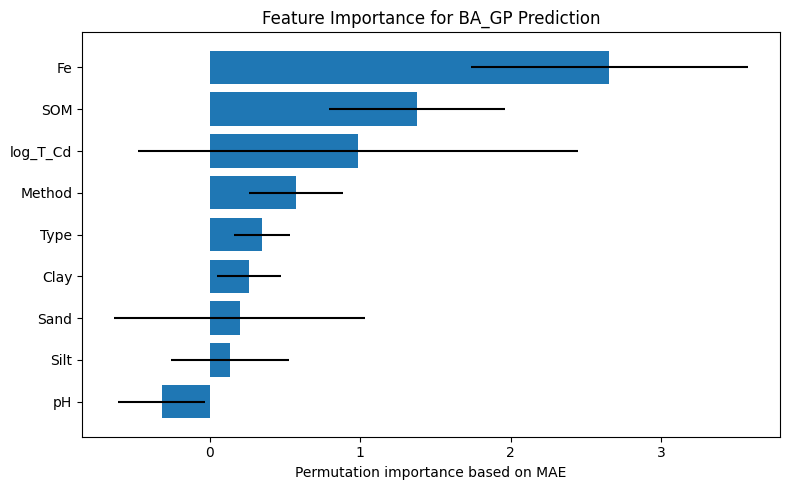

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    xerr=importance_df["Importance_sd"]
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance based on MAE")
plt.title("Feature Importance for BA_GP Prediction")
plt.tight_layout()
plt.savefig(fig_dir / "feature_importance_ba_gp.png", dpi=300)
plt.show()

PDP of factors

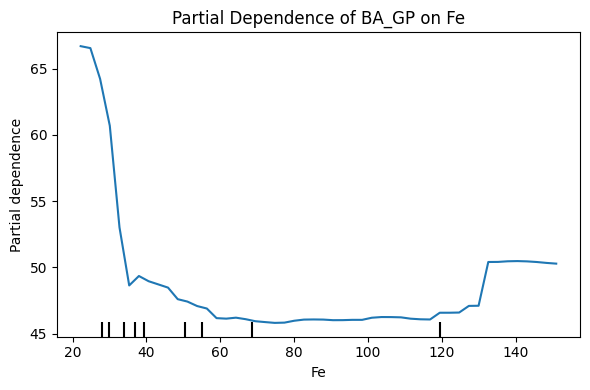

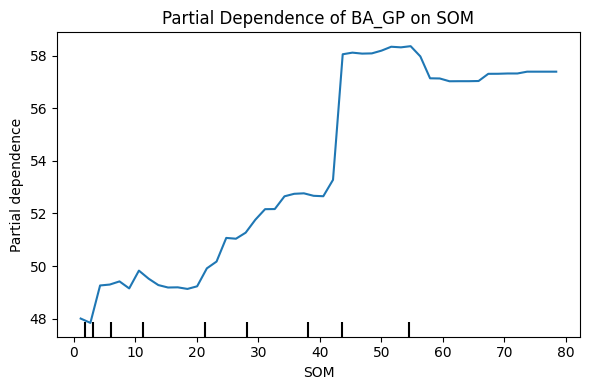

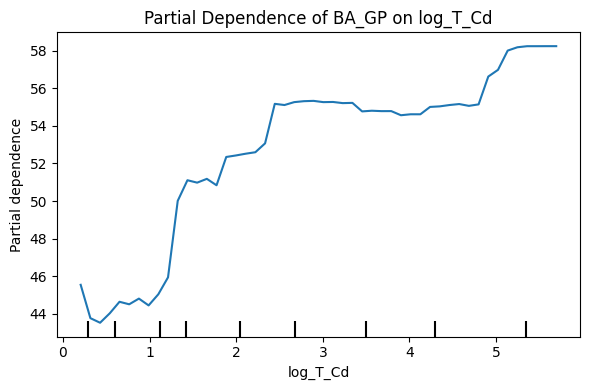

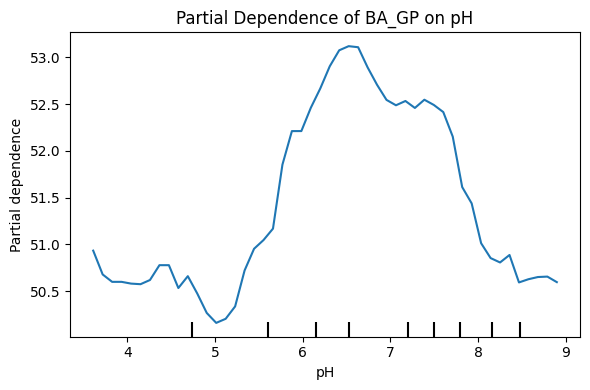

In [26]:
pdp_data = processed_bio.dropna(subset=features + [target]).copy()

X_pdp = pdp_data[features]
y_pdp = pdp_data[target]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

rf_pdp_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=3
    ))
])

rf_pdp_pipe.fit(X_pdp, y_pdp)

pdp_features = ["Fe", "SOM", "log_T_Cd", "pH"]

for feature in pdp_features:
    fig, ax = plt.subplots(figsize=(6, 4))

    PartialDependenceDisplay.from_estimator(
        rf_pdp_pipe,
        X_pdp,
        features=[feature],
        ax=ax,
        grid_resolution=50
    )

    ax.set_title(f"Partial Dependence of BA_GP on {feature}")
    ax.set_ylabel("Predicted BA_GP (%)")
    plt.tight_layout()
    plt.savefig(fig_dir / f"pdp_{feature}_ba_gp.png", dpi=300)
    plt.show()

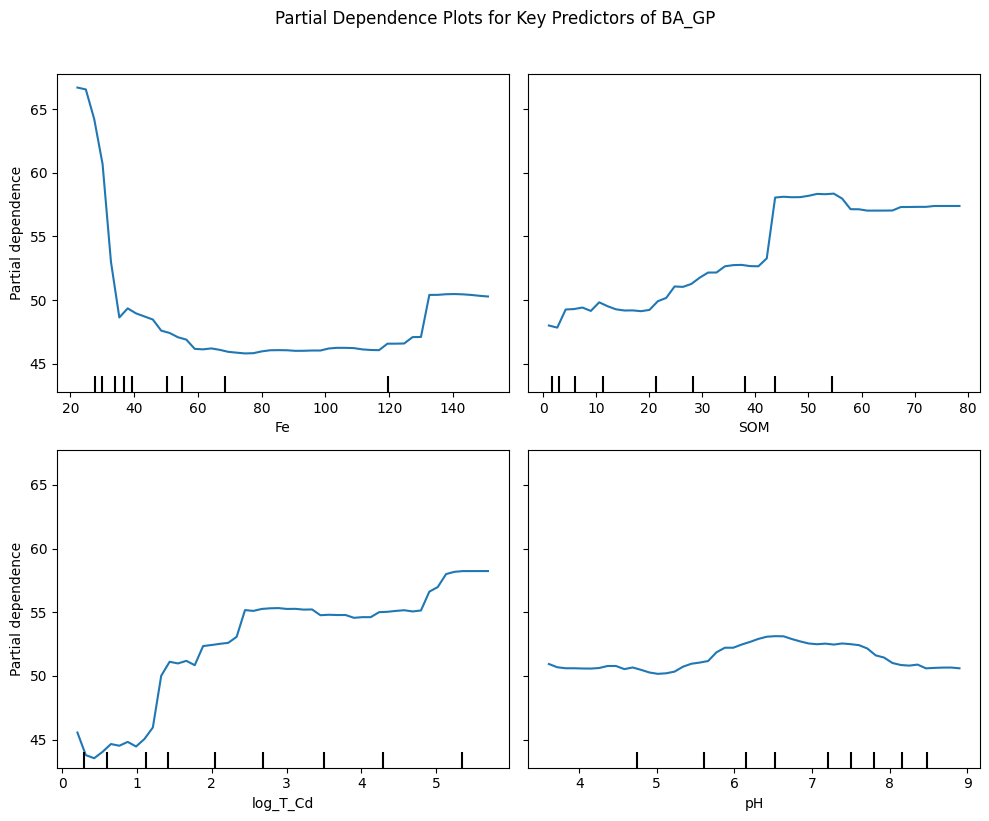

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

PartialDependenceDisplay.from_estimator(
    rf_pdp_pipe,
    X_pdp,
    features=pdp_features,
    ax=ax,
    grid_resolution=50
)

plt.suptitle("Partial Dependence Plots for Key Predictors of BA_GP", y=1.02)
plt.tight_layout()
plt.savefig(fig_dir / "pdp_key_predictors_ba_gp.png", dpi=300, bbox_inches="tight")
plt.show()

## Preliminary interpretation

- Model performance was evaluated using 5-fold cross-validation due to the limited dataset size.
- Total-Cd-only baseline models showed limited predictive ability, suggesting that total Cd concentration alone is insufficient for explaining BA_GP.
- Full-feature models incorporating soil physicochemical properties, digestion method, and soil source type achieved better predictive performance, supporting H1 and H3.
- An additional 80/20 train-test split was used only to visualize observed versus predicted BA_GP.
- Feature importance was estimated using permutation importance on the held-out test split.
- Partial dependence plots were used to explore nonlinear marginal associations between key predictors and model-predicted BA_GP.
- Kruskal-Wallis tests showed that BA_GP differed significantly across digestion methods and soil source types, supporting H2.
- Interpretation should consider the heterogeneity of literature-compiled data and differences among in vitro digestion methods. Feature importance and PDP results indicate model-based associations rather than causal effects.